# 02 · Train and submit

A LightGBM baseline, submitted to the **open round**. About ten minutes.

Coming from [`01_explore_the_data.ipynb`](01_explore_the_data.ipynb). Nothing here spends an
upload until you flip `SUBMIT = True`. Your round-upload allowance is **per event, not per round**.

In [13]:
# Install only what is missing. Re-running this cell on a machine that already has
# the SDK should not be a network round-trip that tries to upgrade it.
try:
    import everestapi, lightgbm, pandas, pyarrow, numpy, scipy, matplotlib, cloudpickle  # noqa: F401
    assert tuple(map(int, everestapi.__version__.split(".")[:3])) >= (0, 3, 32)
except (ImportError, AssertionError, ValueError):
    %pip install --quiet "everestapi>=0.3.32" lightgbm pandas pyarrow numpy scipy matplotlib cloudpickle

In [14]:
import os
from everestapi import EverestAPI

# Read every credential from the environment, so nothing secret is written into the notebook.
base_url = os.environ.get("EIQ_BASE_URL", "https://app.everesteer.ai")
api_key = os.environ.get("EIQ_API_KEY") or os.environ.get("EVEREST_API_KEY")

# Fail fast with a clear message instead of a cryptic 401/403 deeper in the notebook.
if not api_key:
    raise RuntimeError("Set EIQ_API_KEY (onboarding -> Copy setup command).")

# Only the gated STAGING mirror needs a Cloudflare Access service token; the public
# site does not. The SDK picks the CF_ACCESS_* env vars up automatically when set.
if "staging" in base_url and not (
    os.environ.get("CF_ACCESS_CLIENT_ID") and os.environ.get("CF_ACCESS_CLIENT_SECRET")
):
    raise RuntimeError(
        "Staging is behind Cloudflare Access - set CF_ACCESS_CLIENT_ID / "
        "CF_ACCESS_CLIENT_SECRET, or point EIQ_BASE_URL at the public site."
    )

client = EverestAPI(api_key=api_key, base_url=base_url)
# Only `status` is meaningful here. The health probe is a constant-cost liveness
# check, so its `db` and `dataset` fields are always null by design.
print("connection:", client.health().get("status"))  # -> connection: ok

connection: ok


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# One small palette across every plot in these notebooks, so charts read as one system.
NAVY, TEAL, CORAL, GREY = "#09142F", "#007B63", "#EC9A5F", "#9AA3B2"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GREY, "axes.grid": True, "grid.color": "#E6E9EF",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold",
})

In [ ]:
import pandas as pd

schema = client.get_dataset_schema()
schema_verbose = client.get_dataset_schema(verbose=True)
feature_sets = schema_verbose["feature_sets"]
target_cols = list(schema["targets"])

# The graded column, from the schema - it differs between datasets and is NOT
# necessarily the first entry in `targets`.
PRIMARY_TARGET = schema["primary_target"]

# One value in the encoding means "missing" rather than a low bin. Read it; do not assume -1.
MISSING = (schema.get("feature_encoding") or {}).get("missing")
if MISSING is None:
    MISSING = -1.0

# download_dataset writes a parquet and returns its path. `train` is the labeled split.
train = pd.read_parquet(client.download_dataset(universe="futures", split="train"))

EXPED = "exped"   # each exped = one trading day

# Smallest published set: fewer features, faster. Some datasets publish small/medium/all
# tiers; this one publishes a single set, so min() returns it and there is no wider tier
# to move up to later.
FEATURE_SET_NAME = min(feature_sets, key=lambda n: len(feature_sets[n]))
feature_set = feature_sets[FEATURE_SET_NAME]

def exped_num(e):
    return int(str(e).split("_")[-1])   # "exped_8978" -> 8978, so expeds sort in time order

# Every 4th exped, purely for speed in this walkthrough. Use all of it for real models.
keep_expeds = sorted(train[EXPED].unique(), key=exped_num)[::4]
train = train[train[EXPED].isin(keep_expeds)]

print(f"train {train.shape}")
print(f"features used: {len(feature_set)} from the {FEATURE_SET_NAME!r} set "
      f"({len(feature_sets)} set(s) published)")

## 1. Hold out the tail of train

`validation` cannot be scored locally - its targets are blank - so measure yourself on the end
of the labeled `train` split. Two rules:

- **Hold out the last expeds, not a random sample.** Random rows leak across time.
- **Embargo the boundary.** The target is a forward return, so the last fitting expeds already
  encode what happens over the first holdout expeds. This dataset does not publish the horizon,
  so discard a generous block between the two. `EMBARGO = 20` is a wide round number, not a
  horizon read off the data.

Training on Everesteer's servers has the same trap: a `train(...)` job fits the **whole** split
unless told otherwise. Pass `train_filter={"exped": {"cutoff_lt": <first embargo exped>}}` so the
fit stops before the embargo, as [`starter_hosted.py`](../starter_hosted.py) does.

In [17]:
HOLDOUT_EXPEDS = 100   # the tail of train, kept aside
EMBARGO = 20           # expeds discarded between fit and holdout

ordered = sorted(train[EXPED].unique(), key=exped_num)
holdout_expeds = set(ordered[-HOLDOUT_EXPEDS:])
fit_expeds = set(ordered[: -(HOLDOUT_EXPEDS + EMBARGO)])

fit = train[train[EXPED].isin(fit_expeds)]
holdout = train[train[EXPED].isin(holdout_expeds)].copy()

print(f"fit     {len(fit):>8,} rows over {len(fit_expeds):>4} expeds")
print(f"embargo {'':>8}  {EMBARGO:>4} expeds discarded")
print(f"holdout {len(holdout):>8,} rows over {len(holdout_expeds):>4} expeds")
assert not (fit_expeds & holdout_expeds), "fit and holdout must not share expeds"

fit      106,040 rows over 1511 expeds
embargo             20 expeds discarded
holdout    9,197 rows over  100 expeds


## 2. Train

Trees are the usual default here: they take binned integer features and missing values as they
are, and find interactions without scaling. Ridge is the cheap low-variance alternative and a
good ensemble partner; MLPs need more care on data this noisy.

Hosted `train` covers `lightgbm`, `xgboost`, `ridge`, `mlp` and `random_forest`, plus
`model="custom"` for your own code - see [`starter_hosted.py`](../starter_hosted.py).

`features_matrix` maps the missing value to `NaN`, so LightGBM treats it as missing and not as
a real bin.

In [18]:
import lightgbm as lgb

def features_matrix(df, cols, missing=MISSING):
    # Test the missing value itself rather than a range: a dataset that ever encodes a bin
    # below zero would break a range test silently. Bound as a default so it travels by
    # value with anything that pickles this.
    X = df[cols].astype("float32")
    return X.mask(X == missing)

# Lightly-regularized starting params, not tuned.
model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=6,
    num_leaves=64,
    colsample_bytree=0.1,    # few features per tree -> more diverse trees, less overfit
    min_child_samples=500,   # large leaves -> smoother predictions, less overfit
    random_state=42,
    verbose=-1,
)
model.fit(features_matrix(fit, feature_set), fit[PRIMARY_TARGET])
print("Trained on", f"{len(fit):,}", "rows.")

Trained on 106,040 rows.


## 3. Evaluate on the holdout

CORR is rank correlation between your predictions and the target, computed **within each exped**
and summarised across expeds. 

Sharpe is the sharpe ratio of CORR. Sharpe and max drawdown are display-only diagnostics: they say
whether the edge is consistent, but the board ranks on the round score - CORR20, AIMC and NCORR
blended.

In [19]:
from scipy.stats import spearmanr

holdout["prediction"] = model.predict(features_matrix(holdout, feature_set))

def per_exped_corr(df):
    # Spearman (rank) correlation between prediction and target, one value per exped.
    out = {}
    for e, g in df.groupby(EXPED):
        rho, _ = spearmanr(g["prediction"], g[PRIMARY_TARGET])
        if np.isfinite(rho):
            out[e] = rho
    # Order by exped number so the cumulative curve and drawdown are chronological.
    s = pd.Series(out)
    return s.reindex(sorted(s.index, key=exped_num))

corr = per_exped_corr(holdout.dropna(subset=[PRIMARY_TARGET]))
cum = corr.cumsum()
peak = cum.expanding().max()
drawdown = peak - cum

print(f"Mean CORR {corr.mean():.4f} | Std {corr.std():.4f} | "
      f"Sharpe {corr.mean() / corr.std():.2f} | % positive {(corr > 0).mean() * 100:.0f}%")
print(f"Max drawdown {drawdown.max():.4f}")

Mean CORR 0.0821 | Std 0.2310 | Sharpe 0.36 | % positive 70%
Max drawdown 3.1314


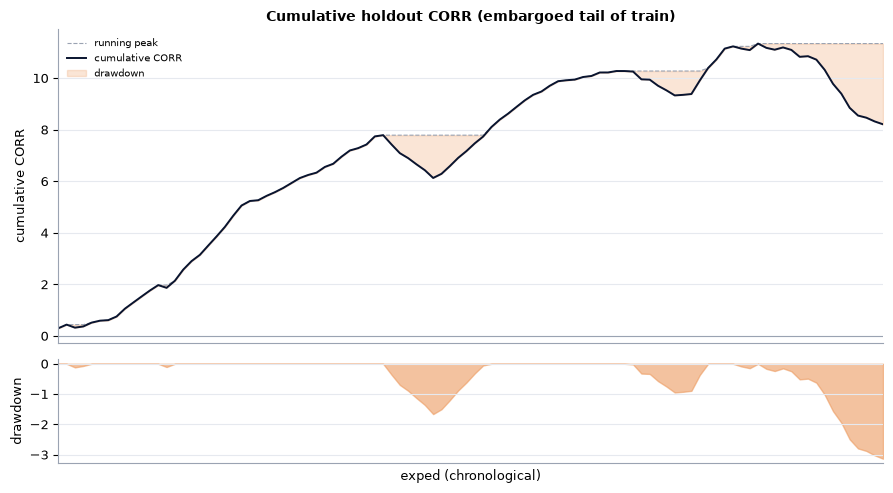

In [20]:
# Cumulative CORR with the drawdown from the running peak shaded underneath.
x = range(len(cum))
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(9, 5), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

ax1.plot(x, peak.values, color=GREY, lw=0.8, ls="--", label="running peak")
ax1.plot(x, cum.values, color=NAVY, lw=1.4, label="cumulative CORR")
ax1.fill_between(x, cum.values, peak.values, color=CORAL, alpha=0.25, label="drawdown")
ax1.axhline(0, color=GREY, lw=0.8)
ax1.set(title="Cumulative holdout CORR (embargoed tail of train)", ylabel="cumulative CORR")
ax1.legend(fontsize=7, frameon=False, loc="upper left")
ax1.margins(x=0)

ax2.fill_between(x, 0, -drawdown.values, color=CORAL, alpha=0.6)
ax2.set(xlabel="exped (chronological)", ylabel="drawdown", xticks=[])
ax2.margins(x=0)
plt.tight_layout(); plt.show()

## 4. Where would this rank?

Both read-only, both safe without an open round.

- `get_diagnostics_leaderboard()`, the event board. `rank_metric` on the response says what it
  was ordered by.
- `download_benchmark("futures", "train")`, the baseline to beat. Our holdout came out of
  `train`, so the comparison is like-for-like. The `validation` and `live` benchmark splits are
  withheld while an event runs and 404 by design.

In [21]:
try:
    lb = client.get_diagnostics_leaderboard()
    entries = lb.get("entries") or lb.get("leaderboard") or []
    print(f"Event board: {len(entries)} entries | ranked on: {lb.get('rank_metric', 'unknown')}")
    for e in entries[:5]:
        name = e.get("model_name") or e.get("agent_name") or e.get("name") or "-"
        score = e.get("round_score") or e.get("score") or e.get("corr")
        print(f"  #{e.get('rank', '?'):>3}  {name:<32}"
              + (f"  {score:.4f}" if isinstance(score, (int, float)) else ""))
except Exception as e:
    print("Event board unavailable:", e)

try:
    bench = pd.read_parquet(client.download_benchmark("futures", "train"))
    baseline = pd.DataFrame({
        "benchmark": bench[[c for c in bench.columns if c != EXPED]].mean(axis=1),
        "bench_exped": bench[EXPED],
    })
    # Join on the id index, and keep a row only where the exped agrees too: a benchmark built
    # from an older train file can share ids with this one on different expeds, and an
    # id-only join would score it against the wrong rows.
    rows = holdout.dropna(subset=[PRIMARY_TARGET]).join(baseline, how="inner")
    rows = rows[rows["bench_exped"] == rows[EXPED]]
    if len(rows) < 0.5 * len(holdout):
        raise ValueError(
            f"only {len(rows):,} of {len(holdout):,} holdout rows match on id and exped, so "
            "the benchmark was built from a different train file than the one served now"
        )
    bench_corr = pd.Series({
        e: spearmanr(g["benchmark"], g[PRIMARY_TARGET])[0] for e, g in rows.groupby(EXPED)
    }).replace([np.inf, -np.inf], np.nan).dropna()
    print(f"\nBenchmark mean CORR : {bench_corr.mean():+.4f}"
          f"  ({len(rows):,} of {len(holdout):,} holdout rows matched)")
    print(f"This baseline       : {corr.mean():+.4f}")
except Exception as e:
    print("\nBenchmark unavailable:", e)

Event board: 2 entries | ranked on: round_score
  #  1  euler-adaptive-quantile           0.2004
  #  2  bellman-biased-portfolio          0.1553

Benchmark mean CORR : +0.0082  (9,197 of 9,197 holdout rows matched)
This baseline       : +0.0821


## 5. Submit to the open round

**Two upload lanes, and they are not interchangeable:**

| lane | tool | what it scores |
|---|---|---|
| the open round. What you are ranked on | `submit_event_predictions` | that round's sealed answer key |
| the practice board, display-only | `submit_validation_diagnostics` | the fixed `validation` split |

They take the same arguments, so swapping them is easy and expensive: the upload is accepted
(202 pending), then fails minutes later on zero id overlap, because the two splits are disjoint
`id` namespaces. You lose the upload and the round.

- **Predict `live`, downloaded fresh.** Each round is a new `id` namespace.
- **Attach the pickle.** Uploads are rejected without `model_pkl`, and the artifact must be a
  cloudpickled *callable*. `model_pkl_python_version` names the interpreter that saved it.
- Submitting **is** entering. There is no nomination step.
- Several models ready at once? Over MCP, `submit_event_predictions_batch` takes 25 items in one
  call. On the Python client, loop.

In [22]:
import cloudpickle
import sys

MODEL_NAME = "hello-everesteer-baseline"
MODEL_ID = None         # filled in at submit time; a name is not a model_id
SUBMIT = False          # flip to True when you're ready to spend an upload


def scored_split_now():
    """('live'|'validation', frame) - the split being scored right now, never a silent swap.

    Only one state is a round you can enter. `intake_fenced` fences ROUND submissions only:
    it is also true in build and between rounds, where no round's data is open, and the
    practice board takes uploads there regardless. So branch on the phase and the window
    first, and wait on the fence only while a round is named.
    """
    cadence = (client.get_status() or {}).get("cadence") or {}
    phase, window = cadence.get("phase"), cadence.get("open_window")

    if phase == "done":
        raise RuntimeError(f"The event is over (phase={phase!r}): no round is being scored.")
    if window and cadence.get("intake_fenced"):   # the round is opening or closing
        raise RuntimeError(
            f"Round {window!r} is not taking predictions yet (phase={phase!r}) - re-run once "
            "cadence.intake_fenced goes false. Do not fall back to the practice board here: it "
            "is display-only and never ranked, so these predictions would not enter any round."
        )
    if window:                              # a round is open: this is what you are ranked on
        return "live", pd.read_parquet(
            client.download_dataset(universe="futures", split="live")
        )
    if cadence.get("diagnostics_maintenance"):
        raise RuntimeError("The practice board is briefly down for maintenance - retry later.")
    print(f"No round open (phase={phase!r}): the practice board is what is open.")
    return "validation", pd.read_parquet(
        client.download_dataset(universe="futures", split="validation")
    )


scored_split, live = scored_split_now()
print(f"Scored split in hand: {scored_split}  ({len(live):,} rows)")

live_ids = live["id"] if "id" in live.columns else live.index
submission = pd.DataFrame(
    {"prediction": model.predict(features_matrix(live, feature_set))},
    index=pd.Index(live_ids, name="id"),
)
submission.to_parquet("hello_everesteer_preds.parquet")


# Everesteer runs ONE artifact shape: a cloudpickled CALLABLE returning a single-column
# DataFrame indexed by instrument id. A bare estimator, or a dict wrapping one, is refused.
def build_predict(fitted, cols):
    def predict(live_features, live_benchmark_models=None):
        return pd.DataFrame(
            {"prediction": fitted.predict(features_matrix(live_features, cols))},
            index=live_features.index,
        )

    return predict


with open("hello_everesteer_model.pkl", "wb") as f:
    cloudpickle.dump(build_predict(model, feature_set), f)

# Pre-flight the payload here: client.validate_submission() is the TOURNAMENT pre-flight and
# does not apply to these lanes. An upload spent on a malformed file is one you do not get back.
assert submission.index.name == "id", submission.index.name
assert list(submission.columns) == ["prediction"], submission.columns
assert submission.index.is_unique, "duplicate ids"
assert submission["prediction"].notna().all(), "NaN predictions"
assert len(submission) == len(live), "row count must match the served split"
print(f"Payload OK: {len(submission):,} unique ids, no NaNs.")

if SUBMIT:
    # A model must EXIST before you can submit for it - submitting to an unknown name is a
    # 404. Reuse the same model across rounds so its board history stays on one entry.
    listed = client.get_models() or {}
    existing = {m.get("name"): m.get("id") for m in (listed.get("models") or [])}
    MODEL_ID = existing.get(MODEL_NAME)
    if MODEL_ID is None:
        MODEL_ID = client.create_model(name=MODEL_NAME, description="notebook baseline")["id"]
    print(f"Model {MODEL_NAME!r} -> {MODEL_ID}")

    # The lane follows the split we actually got, never the one we wanted.
    submit = (client.submit_event_predictions if scored_split == "live"
              else client.submit_validation_diagnostics)
    print(f"Submitting down the {'event' if scored_split == 'live' else 'practice'} lane.")
    print("Submitted:", submit(
        model_id=MODEL_ID,
        predictions="hello_everesteer_preds.parquet",
        model_pkl="hello_everesteer_model.pkl",
        model_pkl_python_version=f"{sys.version_info.major}.{sys.version_info.minor}",
    ))

RuntimeError: The event is over (phase='done'): no round is being scored.

## 6. Read your result, then go again

- `get_diagnostics_leaderboard()`, this round's board.
- `get_diagnostics_standings()`, the cumulative standings across rounds. Those decide a
  display-only event; on a money event the final stake balance does.

Treat each round as its own event: rounds cover different periods, so neither the level nor the
ordering of your candidates transfers reliably between them. **Do not skip a round** - a miss is
not scored as a zero, since the standings carry the exped-weighted *mean* of your round scores,
but it is one fewer chance to raise that mean.

In [ ]:
try:
    standings = client.get_diagnostics_standings()
    rows = standings.get("entries") or standings.get("standings") or []
    print(f"Cumulative standings: {len(rows)} entries")
    for r in rows[:10]:
        name = r.get("model_name") or r.get("agent_name") or r.get("name") or "-"
        total = r.get("cumulative_score") or r.get("total") or r.get("score")
        print(f"  #{r.get('rank', '?'):>3}  {name:<32}"
              + (f"  {total:.4f}" if isinstance(total, (int, float)) else ""))
except Exception as e:
    print("Standings unavailable (they populate once a round has scored):", e)

if MODEL_ID:
    print("\nsubmission status:", client.get_submission_status(model_id=MODEL_ID))

## What to try next

- **Use all of the data.** The setup cell keeps every 4th exped for speed. This dataset
  publishes a single feature set (`all`), so there is no wider tier to move to: the lever here
  is expeds, not feature sets.
- **Auxiliary targets.** Train on the dataset's other targets and ensemble; drop NaN-target
  rows, and keep only one of any near-inverse pair.
- **Feature neutralization.** Reducing exposure to dominant feature groups lifts NCORR and AIMC.
  NCORR neutralizes against 10 core features (`core_feature_overlap` in the schema), and all 10
  sit inside `all`, so you cannot avoid them by picking features.
- **Fit on Everesteer's servers.** [`starter_hosted.py`](../starter_hosted.py) runs the fit
  there for a few cents, then scores the model on its own holdout and wraps it here. Use the
  server only to fit: don't select on the job's own CV numbers, and never upload the `.pkl` it
  returns as-is.
- **Optimise the round score, not CORR alone.** `explain_scoring` reports the live weights.

Full agent contract, staking surface and research skills: [`AGENTS.md`](../AGENTS.md).